In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np

In [ ]:
base_path = "/content/drive/MyDrive/glasses_dataset/train"

glasses_path = os.path.join(base_path, "glasses")
noglasses_path = os.path.join(base_path, "noglasses")

In [ ]:
aug_glasses = "/content/drive/MyDrive/glasses_dataset/augmented/glasses"
aug_noglasses = "/content/drive/MyDrive/glasses_dataset/augmented/noglasses"

os.makedirs(aug_glasses, exist_ok=True)
os.makedirs(aug_noglasses, exist_ok=True)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

In [ ]:
def augment_images(input_path, output_path, target_count=250):

    images = os.listdir(input_path)
    count = 0

    for img_name in images:

        img_path = os.path.join(input_path, img_name)

        img = load_img(img_path, target_size=(224,224))
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        i = 0

        for batch in datagen.flow(
            x,
            batch_size=1,
            save_to_dir=output_path,
            save_prefix='aug',
            save_format='jpg'
        ):

            i += 1
            count += 1

            if count >= target_count:
                return

            if i >= 5:
                break

In [ ]:
augment_images(glasses_path, aug_glasses, target_count=250)

KeyboardInterrupt: 

In [ ]:
augment_images(noglasses_path, aug_noglasses, target_count=250)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
train_dir = "/content/drive/MyDrive/glasses_dataset/train"
val_dir = "/content/drive/MyDrive/glasses_dataset/validation"
test_dir = "/content/drive/MyDrive/glasses_dataset/test"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 597 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 267s 14s/step - accuracy: 0.5578 - loss: 0.7295 - val_accuracy: 0.7000 - val_loss: 0.5900
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7722 - loss: 0.5005 - val_accuracy: 0.7250 - val_loss: 0.5452
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8224 - loss: 0.3957 - val_accuracy: 0.7000 - val_loss: 0.5208
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8492 - loss: 0.3521 - val_accuracy: 0.7250 - val_loss: 0.4580
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9045 - loss: 0.2852 - val_accuracy: 0.7250 - val_loss: 0.4356
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.8878 - loss: 0.2825 - val_accuracy: 0.7250 - val_loss: 0.4777
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9179 - loss: 0.2365 - val_accuracy: 0.7500 - val_loss: 0.4135
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.9246 - loss: 0.2240 - val_accuracy: 0.7500 - val_los

In [ ]:
model.save("glasses_classifier.h5")

In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/glasses_classifier.h5"

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
!find /content/drive/MyDrive -type d | grep -i test

/content/drive/MyDrive/glasses_dataset/test
/content/drive/MyDrive/glasses-detection/test


In [ ]:
import os

base = "/content/drive/MyDrive/glasses_dataset"

for root, dirs, files in os.walk(base):
    print(root)

/content/drive/MyDrive/glasses_dataset
/content/drive/MyDrive/glasses_dataset/test
/content/drive/MyDrive/glasses_dataset/train
/content/drive/MyDrive/glasses_dataset/train/glasses
/content/drive/MyDrive/glasses_dataset/train/noglasses
/content/drive/MyDrive/glasses_dataset/validation
/content/drive/MyDrive/glasses_dataset/validation/glasses
/content/drive/MyDrive/glasses_dataset/validation/noglasses


In [ ]:
import os

for item in os.listdir("/content/drive/MyDrive/glasses_dataset"):
    print(item)

test
train
validation


In [ ]:
TEST_DIR = "/content/drive/MyDrive/glasses_dataset/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

print(test_ds.class_names)

Found 20 files belonging to 2 classes.
['glasses', 'noglasses']


In [ ]:
import numpy as np

y_true = np.concatenate(
    [y.numpy() for x, y in test_ds]
)

y_prob = model.predict(test_ds)

y_pred = (y_prob > 0.5).astype(int).flatten()

print("Predictions Complete")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions Complete


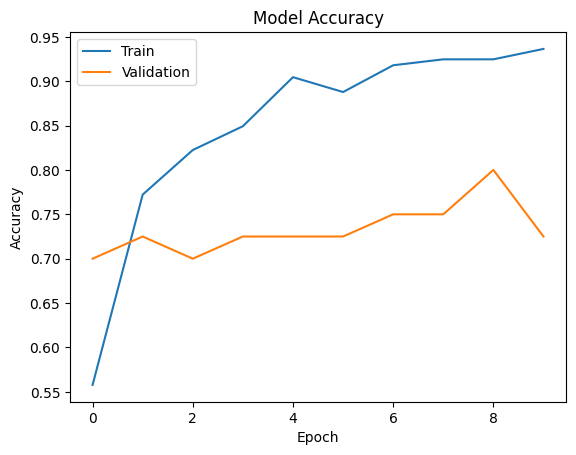

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

print("\n===== RESULTS =====")

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)


===== RESULTS =====
Accuracy : 0.4
Precision: 0.4
Recall   : 0.4
F1 Score : 0.4


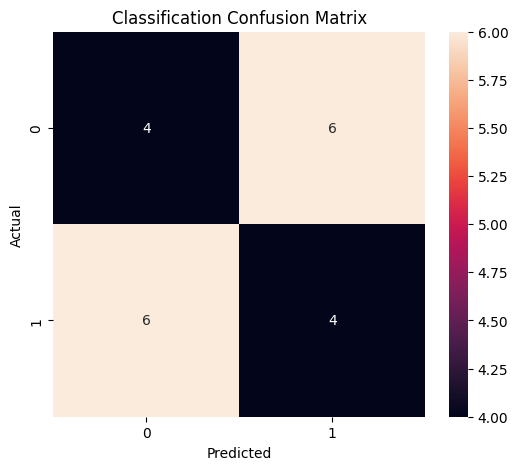

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Classification Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

print("\n===== RESULTS =====")

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)


===== RESULTS =====
Accuracy : 0.4
Precision: 0.4
Recall   : 0.4
F1 Score : 0.4


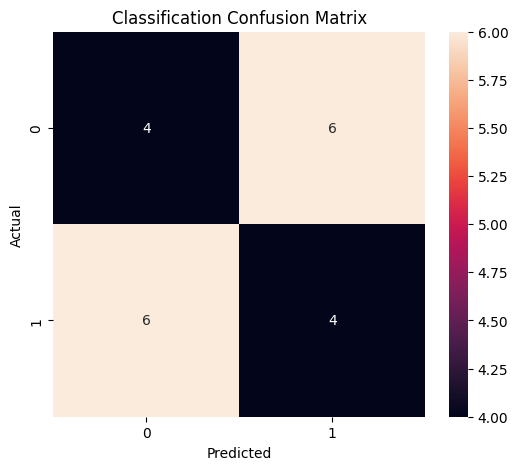

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Classification Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.savefig(
    "classification_confusion_matrix.png"
)

plt.show()

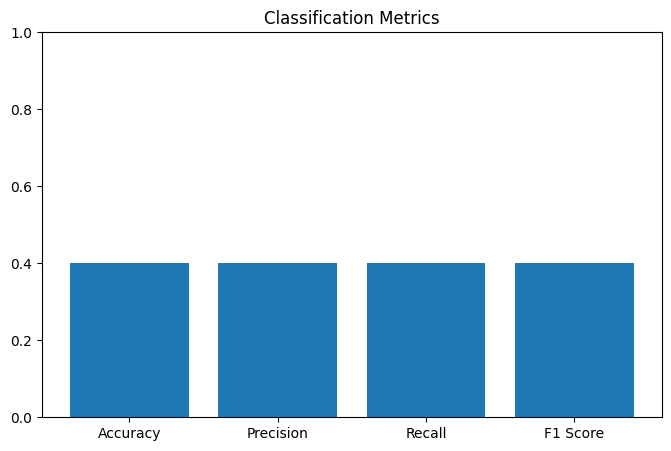

In [ ]:
metrics = [
    accuracy,
    precision,
    recall,
    f1
]

labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

plt.figure(figsize=(8,5))

plt.bar(
    labels,
    metrics
)

plt.ylim(0,1)

plt.title(
    "Classification Metrics"
)

plt.savefig(
    "classification_metrics.png"
)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Accuracy Curve"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid()

plt.savefig(
    "accuracy_curve.png"
)

plt.show()

TypeError: 'History' object is not subscriptable

<Figure size 800x500 with 0 Axes>

In [ ]:
from tensorflow.keras.models import load_model

# Load old model
model = load_model('/content/drive/MyDrive/glasses_classifier.h5',
    compile=False
)

# Save in new format
model.save("glasses_model.keras")

print("Conversion Complete")

Conversion Complete


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 941ms/step
Prediction: No Glasses


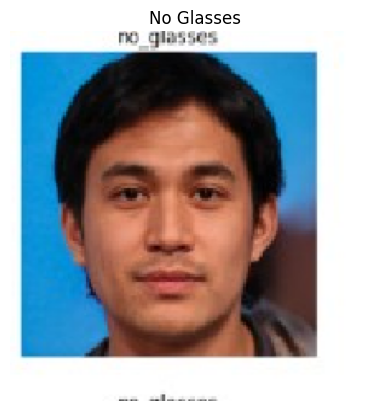

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load model
model = load_model('/content/drive/MyDrive/glasses_classifier.h5')

# Image path
img_path = "/content/drive/MyDrive/glasses_dataset/test/row-7-column-8.jpg"

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert image
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Result
if prediction[0][0] > 0.5:
    result = "No Glasses"
else:
    result = "Glasses"

# Print result
print("Prediction:", result)

# Show image
plt.imshow(img)
plt.title(result)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step
Prediction: Glasses


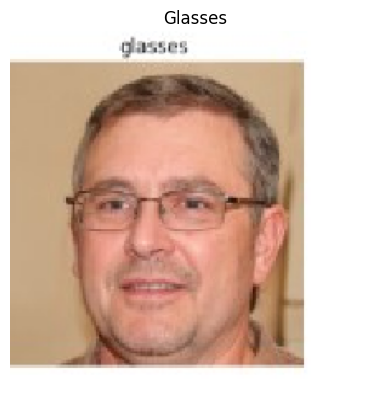

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load model
model = load_model('/content/drive/MyDrive/glasses_classifier.h5')

# Image path
img_path = "/content/drive/MyDrive/glasses_dataset/test/row-1-column-9.jpg"

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert image
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Result
if prediction[0][0] > 0.5:
    result = "No Glasses"
else:
    result = "Glasses"

# Print result
print("Prediction:", result)

# Show image
plt.imshow(img)
plt.title(result)
plt.axis('off')
plt.show()

Saving 1.jpeg to 1.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 814ms/step
Prediction Value: 0.46650288
Prediction: Glasses


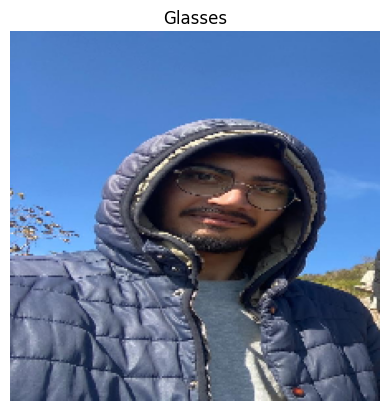

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('/content/drive/MyDrive/glasses_classifier.h5')

# Upload image
uploaded = files.upload()

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Print raw prediction
print("Prediction Value:", prediction[0][0])

# Class labels
# Adjust according to class_indices
if prediction[0][0] > 0.5:
    result = "No Glasses"
else:
    result = "Glasses"

# Show result
print("Prediction:", result)

# Display image
plt.imshow(img)
plt.title(result)
plt.axis('off')
plt.show()

Saving 20260321_130202.jpg to 20260321_130202.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step
Prediction Value: 0.13928682
Prediction: Glasses


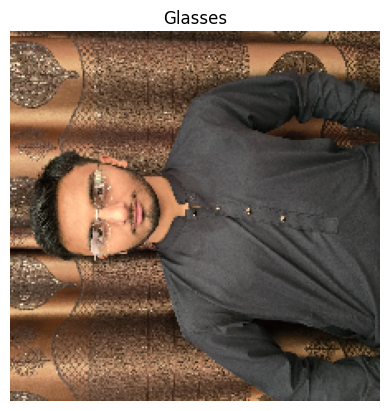

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('/content/drive/MyDrive/glasses_classifier.h5')

# Upload image
uploaded = files.upload()

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Print raw prediction
print("Prediction Value:", prediction[0][0])

# Class labels
# Adjust according to class_indices
if prediction[0][0] > 0.5:
    result = "No Glasses"
else:
    result = "Glasses"

# Show result
print("Prediction:", result)

# Display image
plt.imshow(img)
plt.title(result)
plt.axis('off')
plt.show()

Saving Glasses.jpg to Glasses.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
Prediction Value: 0.253221
Prediction: Glasses


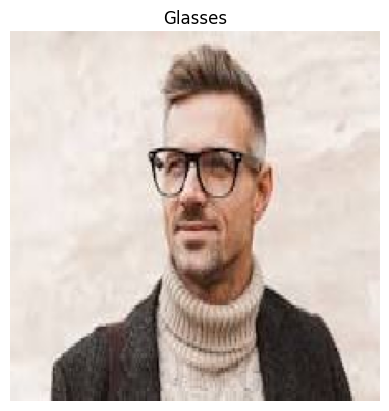

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('/content/drive/MyDrive/glasses_classifier.h5')

# Upload image
uploaded = files.upload()

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Print raw prediction
print("Prediction Value:", prediction[0][0])

# Class labels
# Adjust according to class_indices
if prediction[0][0] > 0.5:
    result = "No Glasses"
else:
    result = "Glasses"

# Show result
print("Prediction:", result)

# Display image
plt.imshow(img)
plt.title(result)
plt.axis('off')
plt.show()

Saving no glasses.jpg to no glasses.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction Value: 0.60116905
Prediction: No Glasses


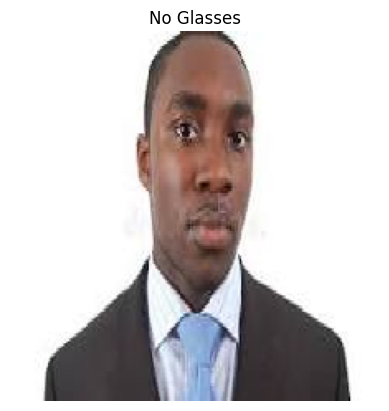

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('/content/drive/MyDrive/glasses_classifier.h5')

# Upload image
uploaded = files.upload()

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Print raw prediction
print("Prediction Value:", prediction[0][0])

# Class labels
# Adjust according to class_indices
if prediction[0][0] > 0.5:
    result = "No Glasses"
else:
    result = "Glasses"

# Show result
print("Prediction:", result)

# Display image
plt.imshow(img)
plt.title(result)
plt.axis('off')
plt.show()

Saving no glasses (2).jpg to no glasses (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 830ms/step
Prediction Value: 0.50002545
Prediction: No Glasses


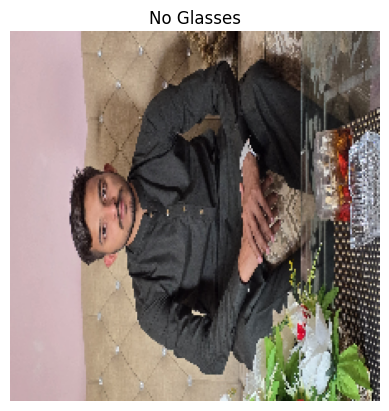

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('/content/drive/MyDrive/glasses_classifier.h5')

# Upload image
uploaded = files.upload()

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Print raw prediction
print("Prediction Value:", prediction[0][0])

# Class labels
# Adjust according to class_indices
if prediction[0][0] > 0.5:
    result = "No Glasses"
else:
    result = "Glasses"

# Show result
print("Prediction:", result)

# Display image
plt.imshow(img)
plt.title(result)
plt.axis('off')
plt.show()

Saving 1.jpeg to 1.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction Value: 0.46650273
Prediction: Glasses


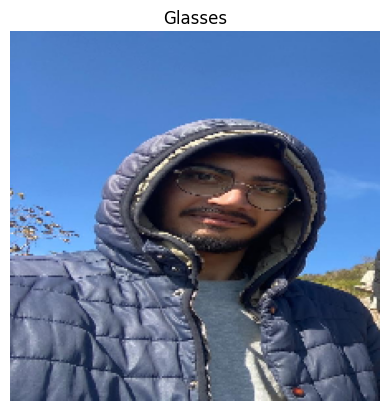

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('/content/drive/MyDrive/glasses_classifier.h5')

# Upload image
uploaded = files.upload()

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Print raw prediction
print("Prediction Value:", prediction[0][0])

# Class labels
# Adjust according to class_indices
if prediction[0][0] > 0.5:
    result = "No Glasses"
else:
    result = "Glasses"

# Show result
print("Prediction:", result)

# Display image
plt.imshow(img)
plt.title(result)
plt.axis('off')
plt.show()